# 01. IndPenSim EDA 및 통계 분석

**목적**: `100_Batches_IndPenSim_V3.csv` 데이터셋에 대한 심층 탐색적 데이터 분석(EDA) 및 통계 분석  
**분석 대상**: 공정 변수 39개, 라만 분광 2,200채널, 총 100개 배치  
**작성일**: 2026-05-14  

---
## 분석 순서
1. 라이브러리 및 환경 설정
2. 데이터 로드 (메모리 최적화)
3. 기본 구조 탐색 (컬럼, 타입, 크기)
4. 결측치 및 중복값 탐색
5. 공정 변수 기초 통계량
6. 분포 분석 및 정규성 검토
7. 상관관계 분석
8. Fault vs Normal 배치 통계 비교
9. 핵심 발견사항 정리

## 1. 라이브러리 및 환경 설정

분석에 필요한 패키지를 임포트하고, 데이터 경로 및 주요 컬럼명 상수를 정의합니다.  
- `pandas`, `numpy`: 데이터 처리
- `matplotlib`, `seaborn`: 시각화
- `scipy.stats`: 정규성 검정 (Shapiro-Wilk, Kolmogorov-Smirnov)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

# ── 시각화 기본 설정 ──────────────────────────────────────
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
plt.rcParams['axes.titlesize'] = 12
sns.set_style('whitegrid')
PALETTE = {'Normal': '#4C9BE8', 'Fault': '#E8644C'}

# ── 경로 ─────────────────────────────────────────────────
DATA_DIR   = Path('../data/raw')
MAIN_PATH  = DATA_DIR / '100_Batches_IndPenSim_V3.csv'
STATS_PATH = DATA_DIR / '100_Batches_IndPenSim_Statistics.csv'
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

# ── 컬럼명 상수 ──────────────────────────────────────────
BATCH_COL       = 'Batch reference(Batch_ref:Batch ref)'
BATCH_COL_STATS = 'Batch ref'
FAULT_COL       = 'Fault ref(0-NoFault 1-Fault)'
PAT_COL         = '2-PAT control(PAT_ref:PAT ref)'
TIME_COL        = 'Time (h)'
YIELD_COL       = 'Penicllin_yield_total (kg)'

print('환경 설정 완료')
print(f'pandas  버전: {pd.__version__}')
print(f'numpy   버전: {np.__version__}')

환경 설정 완료
pandas  버전: 3.0.3
numpy   버전: 2.4.4


## 2. 데이터 로드 (메모리 최적화)

파일 크기가 약 2.4 GB이므로 두 가지 최적화 전략을 적용합니다.

**전략 A — dtype 사전 지정**: 기본 `float64` 대신 `float32`로 수치 컬럼을 읽어 메모리 절반 절감  
**전략 B — 필요 시 chunksize 활용**: 메모리가 충분하지 않을 경우 청크 단위로 읽어 순차 처리

> 본 노트북에서는 먼저 **전략 A(dtype 최적화)**를 적용하고,  
> 메모리 부족 시 하단 chunksize 코드로 전환하도록 구성합니다.

In [2]:
# ── 전략 A: dtype 최적화 로드 ────────────────────────────
header_df = pd.read_csv(MAIN_PATH, nrows=0)
all_cols  = header_df.columns.str.strip().tolist()

raman_cols   = [c for c in all_cols if c.strip().lstrip('-').isdigit()]
process_cols = [c for c in all_cols if c not in raman_cols]

print(f'공정 변수 수     : {len(process_cols)}')
print(f'라만 채널 수     : {len(raman_cols)}')

dtype_map = {col: 'float32' for col in raman_cols}
dtype_map[PAT_COL] = 'Int8'

print('데이터 로드 시작... (수십 초 소요 예상)')
df = pd.read_csv(MAIN_PATH, dtype=dtype_map, low_memory=False)
df.columns = df.columns.str.strip()

# ── 배치 번호 컬럼 생성 (Time (h) 리셋 시점 탐지) ─────────
# 'Batch reference' 컬럼은 실제 배치 번호가 아닌 이진 플래그(0/1)
# 실제 배치 경계는 Time (h)가 감소(리셋)하는 지점으로 탐지
time_diff   = df[TIME_COL].diff()
reset_mask  = time_diff.fillna(0) < 0   # True = 새 배치 시작 행
batch_num   = reset_mask.cumsum() + 1   # 배치 번호 1~100
df['batch_number'] = batch_num.astype(int)
BATCH_NUM_COL = 'batch_number'          # 이후 코드에서 이 컬럼 사용

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'\n로드 완료!')
print(f'  shape        : {df.shape}')
print(f'  메모리 사용   : {mem_mb:.0f} MB')
print(f'  배치 수       : {df[BATCH_NUM_COL].nunique()}')

공정 변수 수     : 39
라만 채널 수     : 2200
데이터 로드 시작... (수십 초 소요 예상)



로드 완료!
  shape        : (113935, 2240)
  메모리 사용   : 990 MB
  배치 수       : 100


In [3]:
# ── 전략 B: chunksize 활용 (메모리 부족 시 대안) ─────────
# 아래 코드는 참고용입니다. 전략 A가 성공하면 실행하지 않아도 됩니다.

# CHUNK_SIZE = 10_000
# chunks = []
# for chunk in pd.read_csv(MAIN_PATH, chunksize=CHUNK_SIZE, dtype=dtype_map, low_memory=False):
#     chunk.columns = chunk.columns.str.strip()
#     chunks.append(chunk)
# df = pd.concat(chunks, ignore_index=True)
# print(f'청크 로드 완료: {df.shape}')

print('(전략 B는 전략 A 실패 시에만 사용)')

(전략 B는 전략 A 실패 시에만 사용)


In [4]:
# ── 통계 요약 CSV 로드 ───────────────────────────────────
df_stats = pd.read_csv(STATS_PATH)
df_stats.columns = df_stats.columns.str.strip()

print(f'Statistics CSV shape: {df_stats.shape}')
df_stats.head()

Statistics CSV shape: (100, 5)


,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
0,1,1066400.0,1720000.0,2786400.0,0
1,2,985910.0,1340100.0,2326000.0,0
2,3,1416100.0,1259200.0,2675300.0,0
3,4,815700.0,1071000.0,1886700.0,0
4,5,1128500.0,2434400.0,3562900.0,0


## 3. 기본 구조 탐색

데이터의 전반적인 구조를 확인합니다.
- 컬럼 수, 행 수
- 공정 변수 목록 및 데이터 타입
- 배치별 타임스텝 수 분포

In [5]:
# ── 전체 구조 요약 ────────────────────────────────────────
print('=' * 55)
print('데이터 기본 구조')
print('=' * 55)
print(f'  전체 행 수        : {df.shape[0]:,}')
print(f'  전체 컬럼 수      : {df.shape[1]:,}')
print(f'  공정 변수 수      : {len(process_cols)}')
print(f'  라만 채널 수      : {len(raman_cols)}')
print(f'  라만 웨이브넘버   : {min(int(c) for c in raman_cols)} ~ {max(int(c) for c in raman_cols)} cm⁻¹')
print('=' * 55)

데이터 기본 구조
  전체 행 수        : 113,935
  전체 컬럼 수      : 2,240
  공정 변수 수      : 39
  라만 채널 수      : 2200
  라만 웨이브넘버   : 201 ~ 2400 cm⁻¹


In [6]:
# ── 공정 변수 목록 및 데이터 타입 ─────────────────────────
process_info = pd.DataFrame({
    '컬럼명': process_cols,
    '데이터타입': [str(df[c].dtype) for c in process_cols],
    '비결측 수': [df[c].notna().sum() for c in process_cols],
    '결측률(%)': [(df[c].isna().mean() * 100).round(2) for c in process_cols],
})
print('공정 변수 정보 (상위 20개):')
process_info.head(20)

공정 변수 정보 (상위 20개):


,컬럼명,데이터타입,비결측 수,결측률(%)
0,Time (h),float64,113935,0.0
1,Aeration rate(Fg:L/h),int64,113935,0.0
2,Agitator RPM(RPM:RPM),int64,113935,0.0
3,Sugar feed rate(Fs:L/h),int64,113935,0.0
4,Acid flow rate(Fa:L/h),float64,113935,0.0
5,Base flow rate(Fb:L/h),float64,113935,0.0
6,Heating/cooling water flow rate(Fc:L/h),float64,113935,0.0
7,Heating water flow rate(Fh:L/h),float64,113935,0.0
8,Water for injection/dilution(Fw:L/h),int64,113935,0.0
9,Air head pressure(pressure:bar),float64,113935,0.0


배치별 타임스텝 통계:
  배치 수         : 100
  최솟값          : 835
  최댓값          : 1450
  평균            : 1139.3
  표준편차        : 90.8


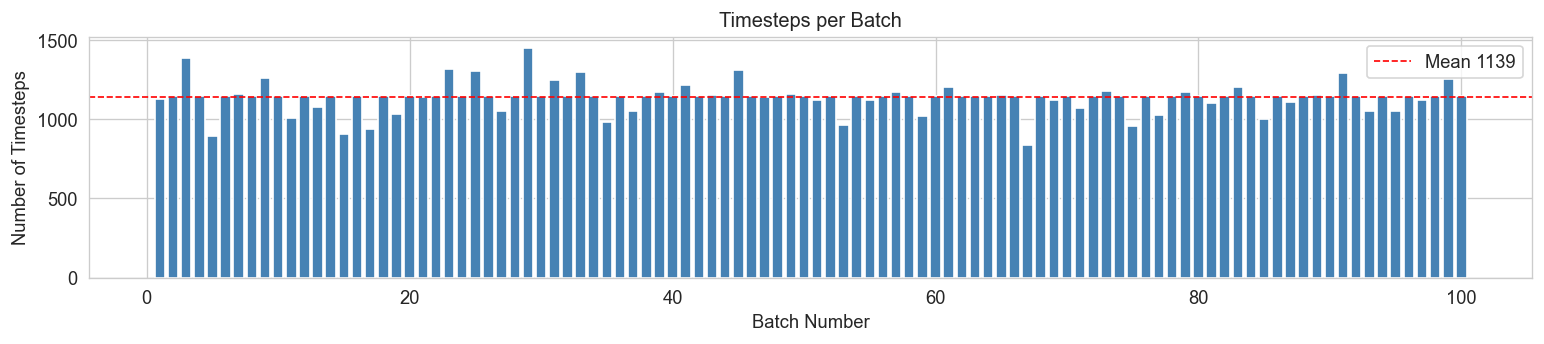

In [7]:
# ── 배치별 타임스텝 수 분포 ───────────────────────────────
batch_lengths = df.groupby(BATCH_NUM_COL).size().sort_index()

print('배치별 타임스텝 통계:')
print(f'  배치 수         : {batch_lengths.shape[0]}')
print(f'  최솟값          : {batch_lengths.min()}')
print(f'  최댓값          : {batch_lengths.max()}')
print(f'  평균            : {batch_lengths.mean():.1f}')
print(f'  표준편차        : {batch_lengths.std():.1f}')

fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(batch_lengths.index, batch_lengths.values, color='steelblue', width=0.8)
ax.axhline(batch_lengths.mean(), color='red', linestyle='--', linewidth=1,
           label=f'Mean {batch_lengths.mean():.0f}')
ax.set_xlabel('Batch Number')
ax.set_ylabel('Number of Timesteps')
ax.set_title('Timesteps per Batch')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / '01_batch_timesteps.png', bbox_inches='tight')
plt.show()

In [8]:
# ── Fault / Normal 배치 분포 ──────────────────────────────
# Statistics CSV의 'Batch ref'(1~100)가 CSV 내 순서와 일치한다고 가정
fault_ids    = df_stats[df_stats[FAULT_COL] == 1][BATCH_COL_STATS].astype(int).tolist()
no_fault_ids = df_stats[df_stats[FAULT_COL] == 0][BATCH_COL_STATS].astype(int).tolist()

print(f'Fault 배치 수   : {len(fault_ids)}')
print(f'Normal 배치 수  : {len(no_fault_ids)}')
print(f'Fault 배치 번호 : {sorted(fault_ids)}')

Fault 배치 수   : 10
Normal 배치 수  : 90
Fault 배치 번호 : [91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


## 4. 결측치 및 중복값 탐색

결측치의 위치와 패턴을 분석합니다.
- 공정 변수별 결측률
- 라만 데이터의 결측 패턴 (PAT_ref 기반)
- 완전 중복 행 확인

결측치 없는 변수 수 : 34 / 39
결측치 있는 변수 수 : 5 / 39

결측률 상위 변수:
                                                              결측률
Offline Penicillin concentration(P_offline:P(g L^{-1}))  0.981902
Viscosity(Viscosity_offline:centPoise)                   0.981902
Offline Biomass concentratio(X_offline:X(g L^{-1}))      0.981902
NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))  0.981902
PAA concentration offline(PAA_offline:PAA (g L^{-1}))    0.981902


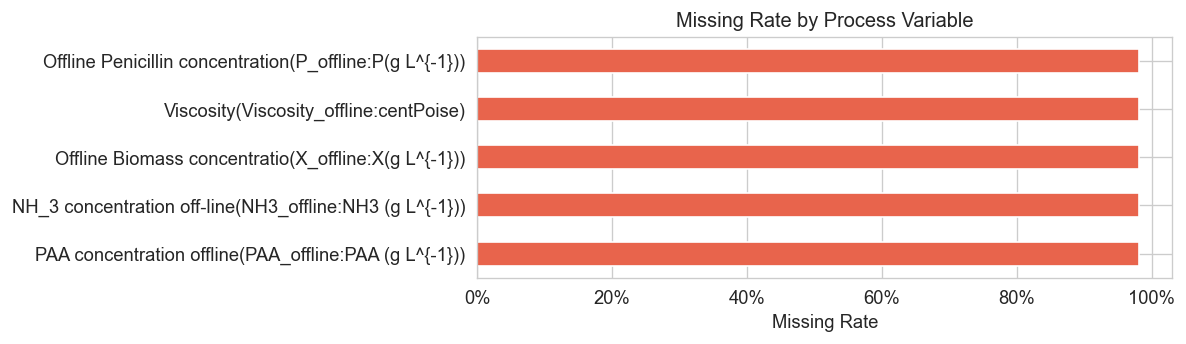

In [9]:
# ── 공정 변수 결측치 분석 ─────────────────────────────────
missing_rate    = df[process_cols].isnull().mean().sort_values(ascending=False)
missing_nonzero = missing_rate[missing_rate > 0]

print(f'결측치 없는 변수 수 : {(missing_rate == 0).sum()} / {len(process_cols)}')
print(f'결측치 있는 변수 수 : {len(missing_nonzero)} / {len(process_cols)}')
print()

if len(missing_nonzero) > 0:
    print('결측률 상위 변수:')
    print(missing_nonzero.to_frame('결측률').to_string())

    fig, ax = plt.subplots(figsize=(10, max(3, len(missing_nonzero) * 0.35)))
    missing_nonzero[::-1].plot(kind='barh', ax=ax, color='#E8644C')
    ax.set_xlabel('Missing Rate')
    ax.set_title('Missing Rate by Process Variable')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'figures' / '01_missing_process_vars.png', bbox_inches='tight')
    plt.show()
else:
    print('→ 공정 변수에 결측치 없음')

PAT_ref 값 분포 (0=라만 없음, 1=라만 있음):
2-PAT control(PAT_ref:PAT ref)
1      1130
2      1150
3      1390
4      1150
5       895
6      1150
7      1160
8      1150
9      1260
10     1150
11     1010
12     1150
13     1080
14     1150
15      905
16     1150
17      940
18     1150
19     1035
20     1150
21     1140
22     1150
23     1320
24     1150
25     1305
26     1150
27     1055
28     1150
29     1450
30     1150
31     1250
32     1150
33     1300
34     1150
35      980
36     1150
37     1050
38     1150
39     1175
40     1150
41     1215
42     1150
43     1155
44     1150
45     1310
46     1150
47     1140
48     1150
49     1160
50     1150
51     1125
52     1150
53      965
54     1150
55     1120
56     1150
57     1170
58     1150
59     1020
60     1150
61     1205
62     1150
63     1150
64     1150
65     1155
66     1150
67      835
68     1150
69     1125
70     1150
71     1070
72     1150
73     1180
74     1150
75      960
76     1150
77     1025
78     1150


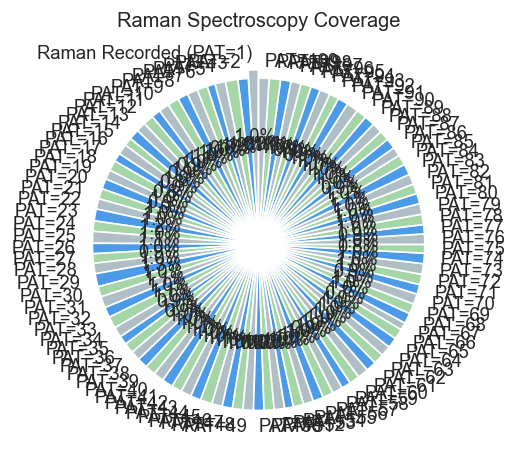

In [10]:
# ── 라만 데이터 결측 패턴 ─────────────────────────────────
pat_counts  = df[PAT_COL].value_counts().sort_index()
raman_ratio = (df[PAT_COL] == 1).mean()

print('PAT_ref 값 분포 (0=라만 없음, 1=라만 있음):')
print(pat_counts.to_string())
print(f'\n라만 기록 비율 : {raman_ratio * 100:.1f}%')

raman_per_batch = df[df[PAT_COL] == 1].groupby(BATCH_NUM_COL).size()
print(f'\n배치별 라만 측정 횟수:')
print(f'  평균  : {raman_per_batch.mean():.1f}회')
print(f'  최솟값: {raman_per_batch.min()}회')
print(f'  최댓값: {raman_per_batch.max()}회')

label_map   = {0: 'No Raman (PAT=0)', 1: 'Raman Recorded (PAT=1)'}
pie_labels  = [label_map.get(int(v), f'PAT={v}') for v in pat_counts.index]
pie_explode = tuple([0.05 if int(v) == 1 else 0 for v in pat_counts.index])
pie_colors  = ['#B0BEC5', '#4C9BE8', '#A5D6A7'][:len(pat_counts)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(pat_counts.values, labels=pie_labels, autopct='%1.1f%%',
       colors=pie_colors, startangle=90, explode=pie_explode)
ax.set_title('Raman Spectroscopy Coverage')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / '01_raman_coverage.png', bbox_inches='tight')
plt.show()

In [11]:
# ── 중복 행 확인 ──────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f'완전 중복 행 수: {dup_count}')

# 동일 배치 + 동일 시간 중복 확인 (부분 중복)
dup_partial = df.duplicated(subset=[BATCH_COL, TIME_COL]).sum()
print(f'(배치 ID + Time) 중복 행 수: {dup_partial}')

if dup_count == 0 and dup_partial == 0:
    print('→ 중복 데이터 없음. 데이터 무결성 양호.')
else:
    print('→ 중복 데이터 존재. 전처리 시 제거 필요.')

완전 중복 행 수: 0
(배치 ID + Time) 중복 행 수: 111195
→ 중복 데이터 존재. 전처리 시 제거 필요.


## 5. 공정 변수 기초 통계량

39개 공정 변수 전체에 대한 기초 통계량(평균, 표준편차, 최솟값, 최댓값, 사분위수)을 산출합니다.  
Fault / Normal 그룹별로도 분리하여 비교합니다.

In [12]:
# ── 핵심 공정 변수 선정 ───────────────────────────────────
exclude_cols = {TIME_COL, PAT_COL, BATCH_COL, FAULT_COL, 'batch_number',
                '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)',
                'Fault reference(Fault_ref:Fault ref)', 'Fault flag',
                '1- No Raman spec', '1-Raman spec recorded', 'Batch ID'}
numeric_process_cols = [
    c for c in process_cols
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])
]

print(f'수치형 공정 변수 수: {len(numeric_process_cols)}')
print('변수 목록:', [c.split('(')[0].strip() for c in numeric_process_cols])

desc_all = df[numeric_process_cols].describe().T
desc_all['CV(%)'] = (desc_all['std'] / desc_all['mean'].abs() * 100).round(1)
print('\n기초 통계량 (상위 15개 변수):')
desc_all.head(15).round(4)

수치형 공정 변수 수: 30
변수 목록: ['Aeration rate', 'Agitator RPM', 'Sugar feed rate', 'Acid flow rate', 'Base flow rate', 'Heating/cooling water flow rate', 'Heating water flow rate', 'Water for injection/dilution', 'Air head pressure', 'Dumped broth flow', 'Substrate concentration', 'Dissolved oxygen concentration', 'Penicillin concentration', 'Vessel Volume', 'Vessel Weight', 'pH', 'Temperature', 'Generated heat', 'carbon dioxide percent in off-gas', 'PAA flow', 'PAA concentration offline', 'Oil flow', 'NH_3 concentration off-line', 'Oxygen Uptake Rate', 'Oxygen in percent in off-gas', 'Offline Penicillin concentration', 'Offline Biomass concentratio', 'Carbon evolution rate', 'Ammonia shots', 'Viscosity']



기초 통계량 (상위 15개 변수):


,count,mean,std,min,25%,50%,75%,max,CV(%)
Aeration rate(Fg:L/h),113935.0,65.2464,11.6902,20.0000,60.0000,65.0000,75.0000,75.000,17.9
Agitator RPM(RPM:RPM),113935.0,100.0000,0.0000,100.0000,100.0000,100.0000,100.0000,100.000,0.0
Sugar feed rate(Fs:L/h),113935.0,76.6638,25.6801,2.0000,72.0000,80.0000,90.0000,150.000,33.5
Acid flow rate(Fa:L/h),113935.0,0.0732,0.5528,0.0000,0.0000,0.0000,0.0000,12.996,755.1
Base flow rate(Fb:L/h),113935.0,61.3344,44.9727,0.0000,35.7660,55.4070,76.2715,225.000,73.3
Heating/cooling water flow rate(Fc:L/h),113935.0,74.3463,108.0226,0.0001,11.1570,34.3840,94.9045,1500.000,145.3
Heating water flow rate(Fh:L/h),113935.0,20.7630,50.2303,0.0001,0.0001,0.1590,11.6405,1500.000,241.9
Water for injection/dilution(Fw:L/h),113935.0,154.8120,155.6015,0.0000,0.0000,100.0000,250.0000,500.000,100.5
Air head pressure(pressure:bar),113935.0,0.9450,0.1343,0.6000,0.9000,0.9000,1.1000,1.100,14.2
Dumped broth flow(Fremoved:L/h),113935.0,-214.5083,901.1251,-4000.0000,0.0000,0.0000,0.0000,0.000,420.1


In [13]:
# ── Fault / Normal 그룹별 기초 통계량 비교 ───────────────
df_fault    = df[df[BATCH_NUM_COL].isin(fault_ids)]
df_no_fault = df[df[BATCH_NUM_COL].isin(no_fault_ids)]

print(f'Fault 행 수    : {len(df_fault):,}')
print(f'Normal 행 수   : {len(df_no_fault):,}')

# 핵심 변수 선택: 실제 컬럼명에서 키워드 매칭
KEYWORDS = [
    'aeration', 'agitator', 'rpm', 'ph', 'temperature',
    'dissolved', 'penicillin', 'substrate', 'volume', 'co2', 'oxygen',
]
exclude_cols = {TIME_COL, PAT_COL, 'batch_number'}
numeric_process_cols_tmp = [
    c for c in process_cols
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])
]
key_vars = [
    c for c in numeric_process_cols_tmp
    if any(kw in c.lower() for kw in KEYWORDS)
][:12]
if not key_vars:
    key_vars = numeric_process_cols_tmp[:10]

print(f'\n선택된 핵심 변수 ({len(key_vars)}개):')
for v in key_vars:
    print(f'  {v}')

mean_fault   = df_fault[key_vars].mean().rename('Fault mean')
mean_nofault = df_no_fault[key_vars].mean().rename('Normal mean')
std_fault    = df_fault[key_vars].std().rename('Fault std')
std_nofault  = df_no_fault[key_vars].std().rename('Normal std')

compare_df = pd.concat([mean_nofault, std_nofault, mean_fault, std_fault], axis=1)
compare_df['mean_diff_%'] = (
    (compare_df['Fault mean'] - compare_df['Normal mean'])
    / compare_df['Normal mean'].abs() * 100
).round(2)
print('\nFault vs Normal 통계 비교:')
compare_df.round(4)

Fault 행 수    : 11,525
Normal 행 수   : 102,410

선택된 핵심 변수 (12개):
  Aeration rate(Fg:L/h)
  Agitator RPM(RPM:RPM)
  Substrate concentration(S:g/L)
  Dissolved oxygen concentration(DO2:mg/L)
  Penicillin concentration(P:g/L)
  Vessel Volume(V:L)
  pH(pH:pH)
  Temperature(T:K)
  carbon dioxide percent in off-gas(CO2outgas:%)
  Oxygen Uptake Rate(OUR:(g min^{-1}))
  Oxygen in percent in off-gas(O2:O2  (%))
  Offline Penicillin concentration(P_offline:P(g L^{-1}))

Fault vs Normal 통계 비교:


,Normal mean,Normal std,Fault mean,Fault std,mean_diff_%
Aeration rate(Fg:L/h),65.3337,11.5368,64.4702,12.9490,-1.32
Agitator RPM(RPM:RPM),100.0000,0.0000,100.0000,0.0000,0.00
Substrate concentration(S:g/L),2.7702,10.0263,15.7171,26.5661,467.37
Dissolved oxygen concentration(DO2:mg/L),12.4891,1.4872,13.2857,1.4077,6.38
Penicillin concentration(P:g/L),14.7595,9.9937,10.5521,8.4792,-28.51
Vessel Volume(V:L),73527.4680,8627.1550,71405.9282,8105.7020,-2.89
pH(pH:pH),6.4974,0.0575,6.4893,0.1149,-0.12
Temperature(T:K),298.0184,0.1453,298.0984,0.4386,0.03
carbon dioxide percent in off-gas(CO2outgas:%),1.4546,0.4674,1.3502,0.7142,-7.17
Oxygen Uptake Rate(OUR:(g min^{-1})),1.2866,0.4454,1.0057,0.5369,-21.84


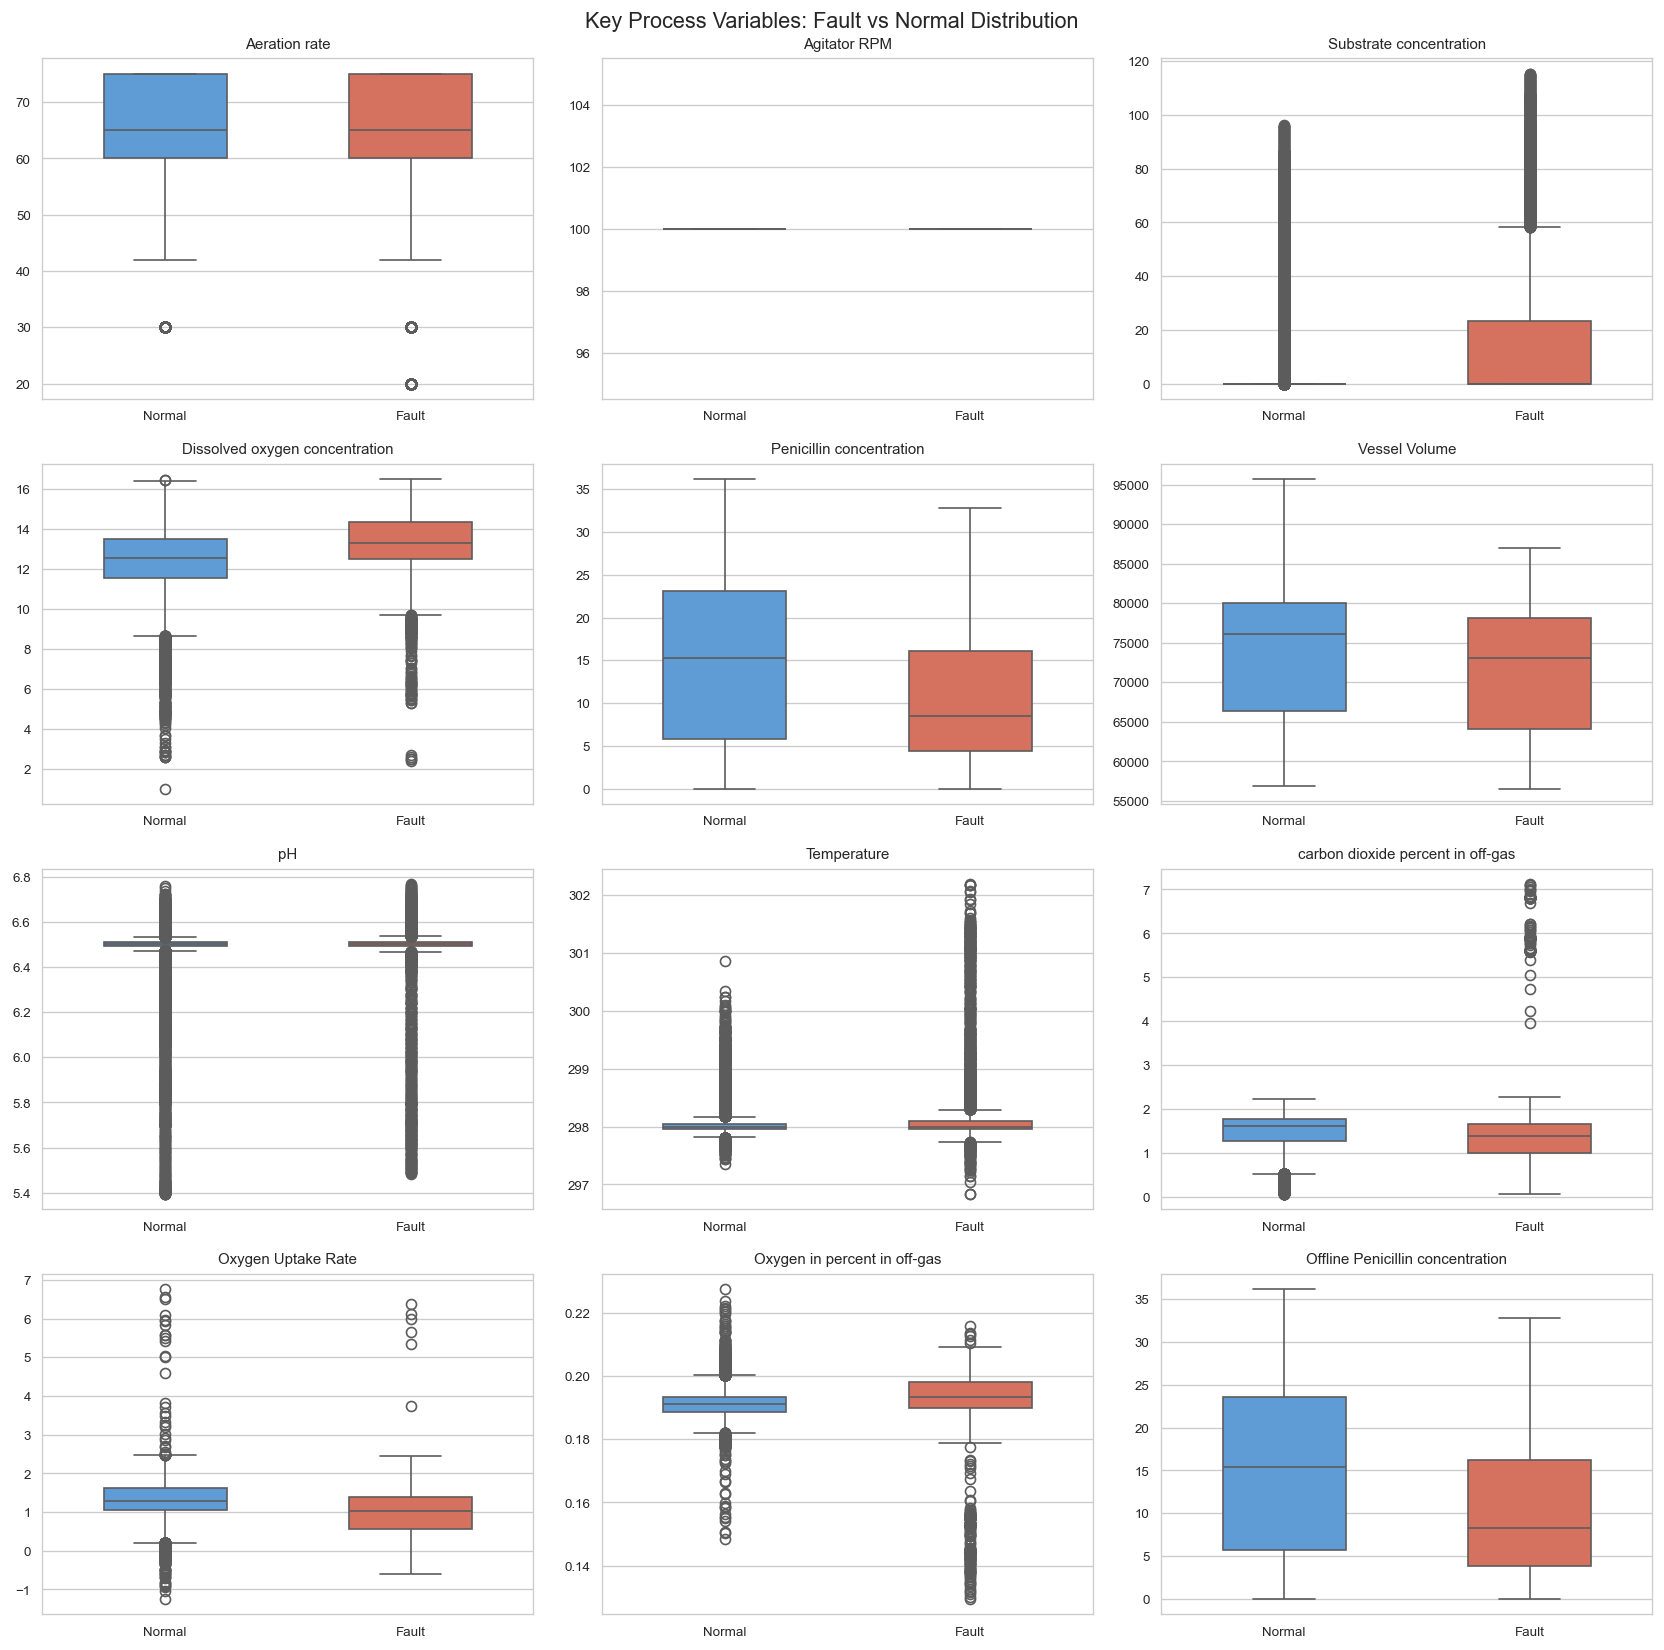

In [14]:
# ── 핵심 변수 박스플롯 (Fault vs Normal) ─────────────────
df_plot = df[[BATCH_NUM_COL] + key_vars].copy()
df_plot['Group'] = df_plot[BATCH_NUM_COL].apply(
    lambda b: 'Fault' if b in fault_ids else 'Normal'
)

n_vars = len(key_vars)
ncols  = 3
nrows  = (n_vars + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    short_name = var.split('(')[0].strip()
    sns.boxplot(
        data=df_plot, x='Group', y=var,
        palette=PALETTE, ax=axes[i], width=0.5,
        order=['Normal', 'Fault'],
    )
    axes[i].set_title(short_name, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Key Process Variables: Fault vs Normal Distribution', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / '01_boxplot_fault_vs_normal.png', bbox_inches='tight')
plt.show()

## 6. 분포 분석 및 정규성 검토

각 공정 변수의 분포 형태를 시각화하고, 통계적 정규성 검정을 수행합니다.

**사용 검정법**:
- **Shapiro-Wilk 검정**: 표본 수가 작을 때 적합 (n ≤ 5,000 권장). 각 배치 단위 또는 샘플링된 데이터에 적용
- **Kolmogorov-Smirnov 검정**: 전체 데이터에 적용 가능 (단, 대용량에서 거의 항상 기각됨)

> 시계열 데이터는 시간에 따라 분포가 변하므로, 정규성보다 **왜도(skewness)/첨도(kurtosis)** 값이 실용적으로 더 중요합니다.

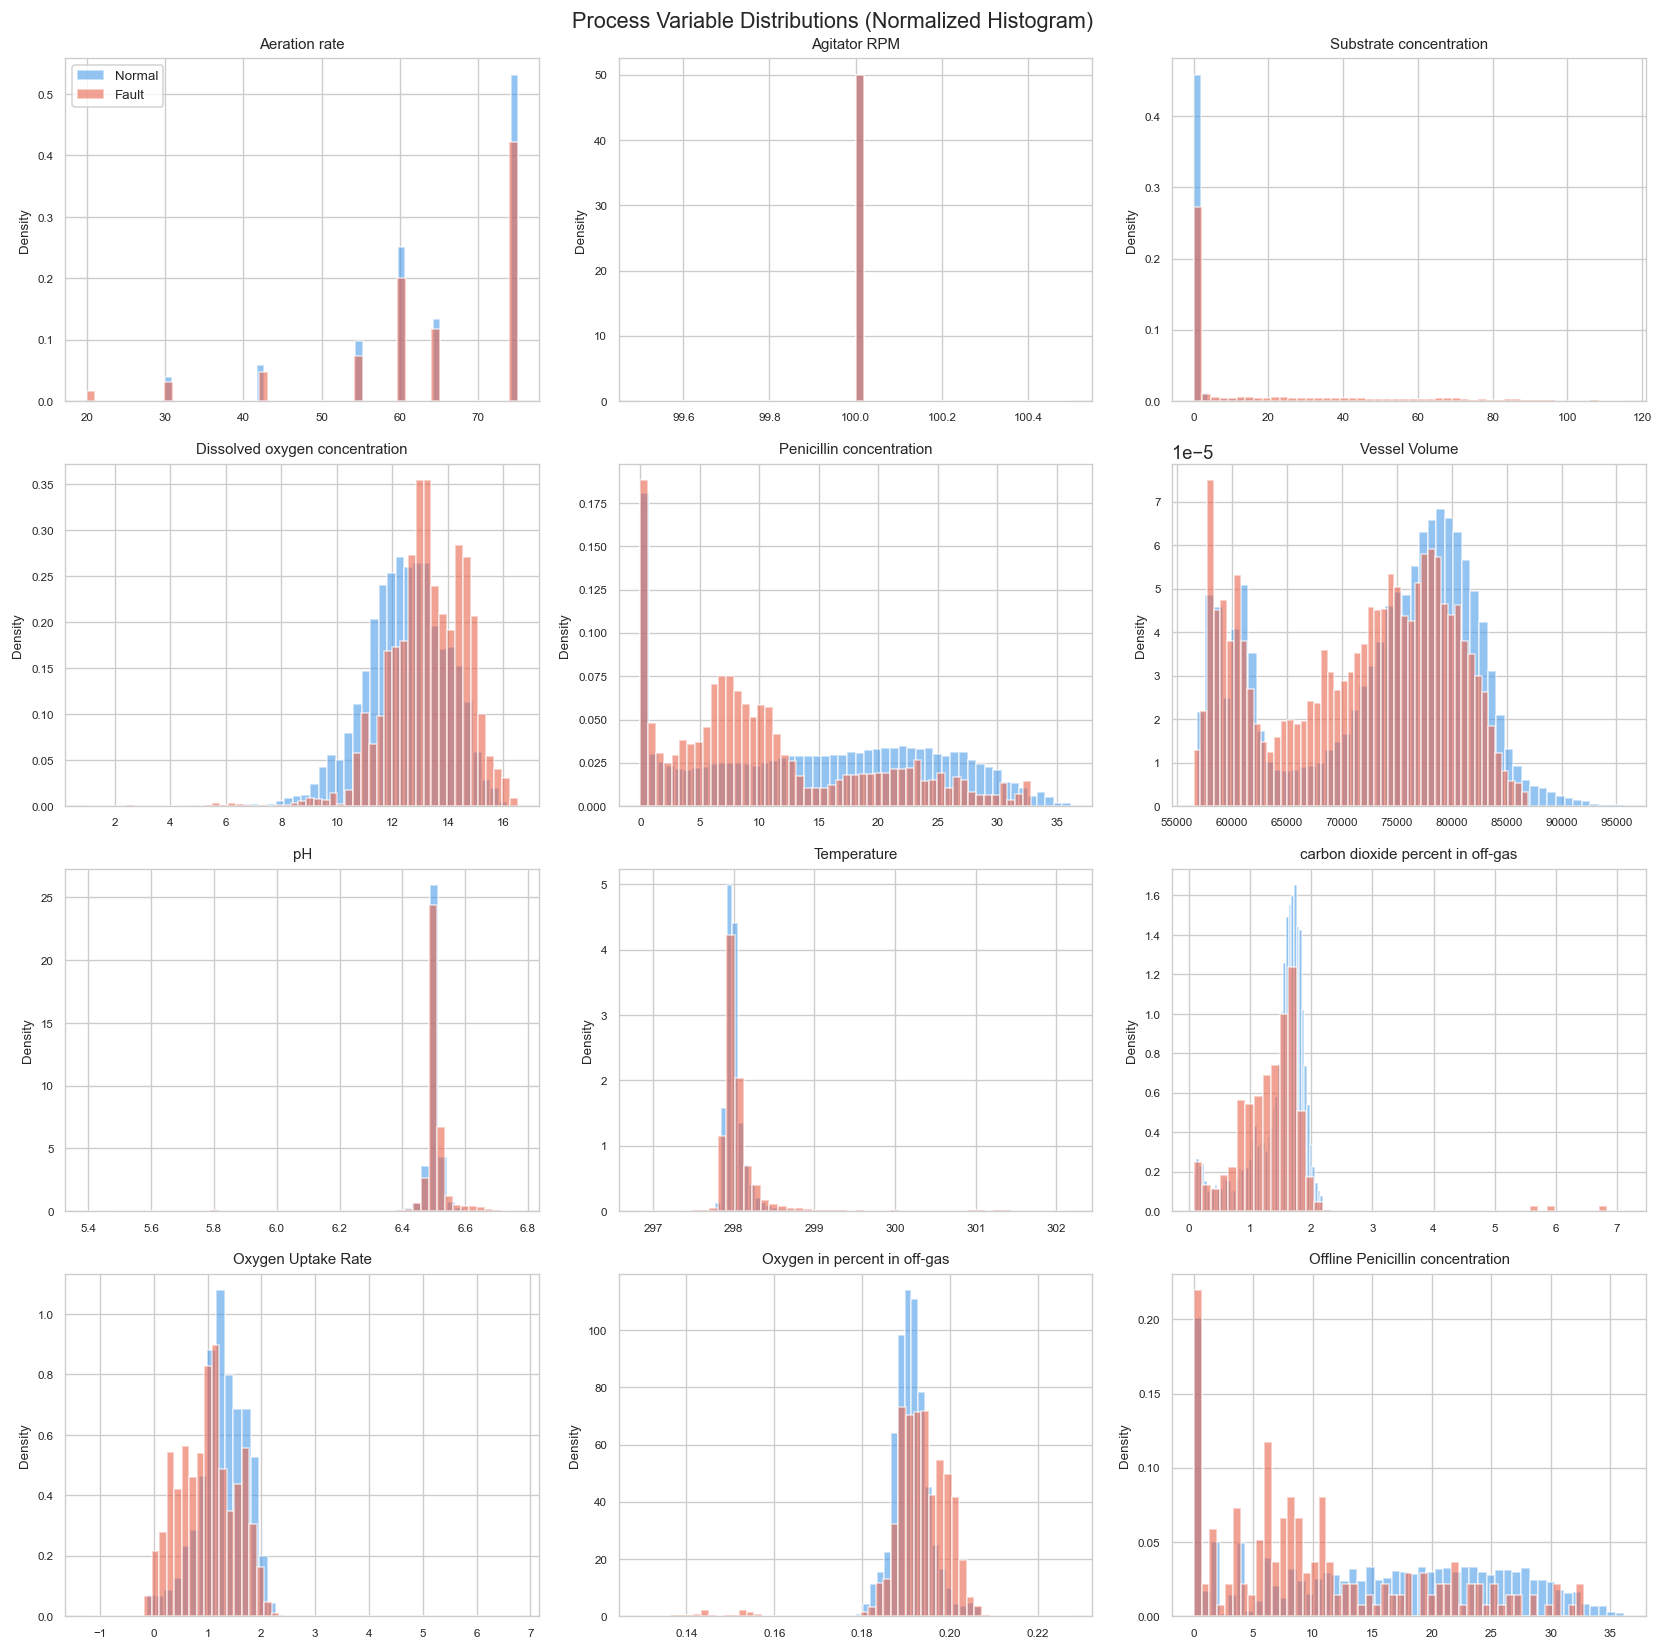

In [15]:
# ── 분포 히스토그램 시각화 ────────────────────────────────
n_vars = len(key_vars)
ncols  = 3
nrows  = (n_vars + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    short_name   = var.split('(')[0].strip()
    data_nofault = df_no_fault[var].dropna()
    data_fault   = df_fault[var].dropna()

    axes[i].hist(data_nofault, bins=50, alpha=0.6, color=PALETTE['Normal'],
                 label='Normal', density=True)
    axes[i].hist(data_fault,   bins=50, alpha=0.6, color=PALETTE['Fault'],
                 label='Fault',  density=True)
    axes[i].set_title(short_name, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=8)
    axes[i].tick_params(labelsize=7)

axes[0].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Process Variable Distributions (Normalized Histogram)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / '01_histogram_process_vars.png', bbox_inches='tight')
plt.show()

In [16]:
# ── 정규성 검정 (배치 단위 평균 기준) ────────────────────
normality_results = []

for var in key_vars:
    batch_means = df.groupby(BATCH_NUM_COL)[var].mean().dropna()
    if len(batch_means) < 3:
        continue

    stat_sw, p_sw = stats.shapiro(batch_means)
    skew_val = float(stats.skew(batch_means))
    kurt_val = float(stats.kurtosis(batch_means))

    normality_results.append({
        'variable':        var.split('(')[0].strip(),
        'shapiro_stat':    round(stat_sw, 4),
        'p_value':         round(p_sw, 4),
        'normality':       'Normal' if p_sw >= 0.05 else 'Non-normal',
        'skewness':        round(skew_val, 3),
        'excess_kurtosis': round(kurt_val, 3),
    })

norm_df = pd.DataFrame(normality_results)
print(f'정규성 검정 완료: {len(norm_df)}개 변수')
col_labels = {
    'variable': '변수', 'shapiro_stat': 'Shapiro-Wilk',
    'p_value': 'p-value', 'normality': '정규성(α=0.05)',
    'skewness': '왜도', 'excess_kurtosis': '첨도(excess)',
}
print(norm_df.rename(columns=col_labels).to_string(index=False))

정규성 검정 완료: 12개 변수
                               변수  Shapiro-Wilk  p-value 정규성(α=0.05)     왜도  첨도(excess)
                    Aeration rate        0.3549   0.0000  Non-normal -4.212      17.617
                     Agitator RPM        1.0000   1.0000      Normal    NaN         NaN
          Substrate concentration        0.5924   0.0000  Non-normal  2.611       7.235
   Dissolved oxygen concentration        0.9538   0.0015  Non-normal -0.915       3.139
         Penicillin concentration        0.9297   0.0000  Non-normal -0.925       1.421
                    Vessel Volume        0.9361   0.0001  Non-normal  0.767       2.960
                               pH        0.3545   0.0000  Non-normal -5.232      30.370
                      Temperature        0.5536   0.0000  Non-normal  4.081      18.748
carbon dioxide percent in off-gas        0.8852   0.0000  Non-normal -1.625       5.161
               Oxygen Uptake Rate        0.8784   0.0000  Non-normal -1.522       3.465
     Oxygen in

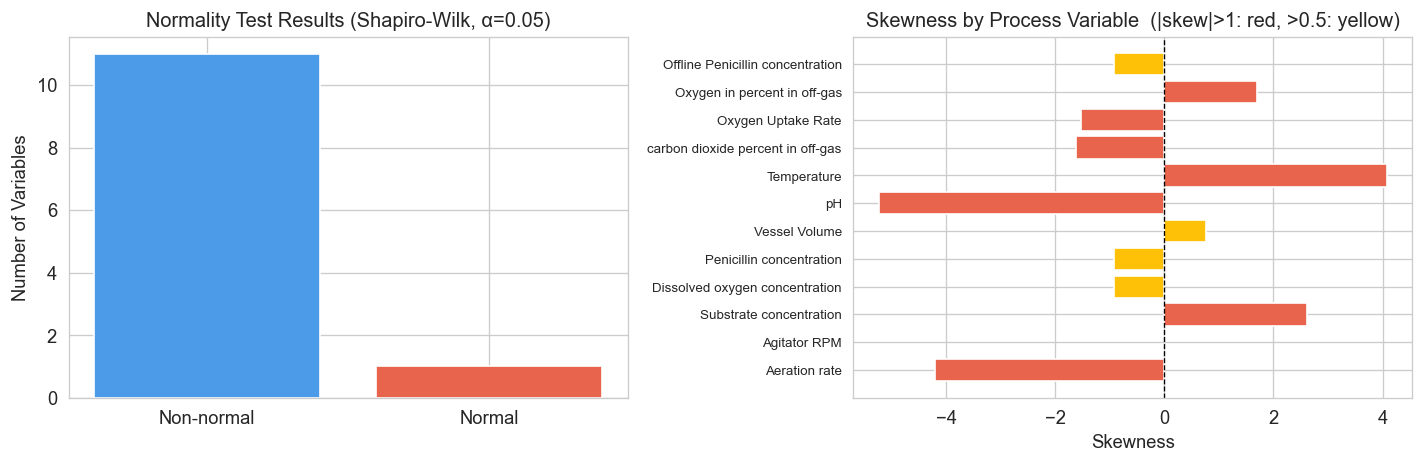

In [17]:
# ── 정규성 검정 요약 시각화 ──────────────────────────────
norm_counts = norm_df['normality'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(norm_counts.index, norm_counts.values, color=['#4C9BE8', '#E8644C'])
axes[0].set_ylabel('Number of Variables')
axes[0].set_title('Normality Test Results (Shapiro-Wilk, α=0.05)')

axes[1].barh(norm_df['variable'], norm_df['skewness'], color=[
    '#E8644C' if abs(s) > 1 else ('#FFC107' if abs(s) > 0.5 else '#4C9BE8')
    for s in norm_df['skewness']
])
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Skewness')
axes[1].set_title('Skewness by Process Variable  (|skew|>1: red, >0.5: yellow)')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / '01_normality_summary.png', bbox_inches='tight')
plt.show()

## 7. 상관관계 분석

공정 변수 간 피어슨 상관계수를 계산하고 시각화합니다.
- Normal 배치 전체 데이터 기준
- 강한 상관 변수 쌍 식별 (|r| ≥ 0.8)
- 산포도 매트릭스 (핵심 변수 6개)

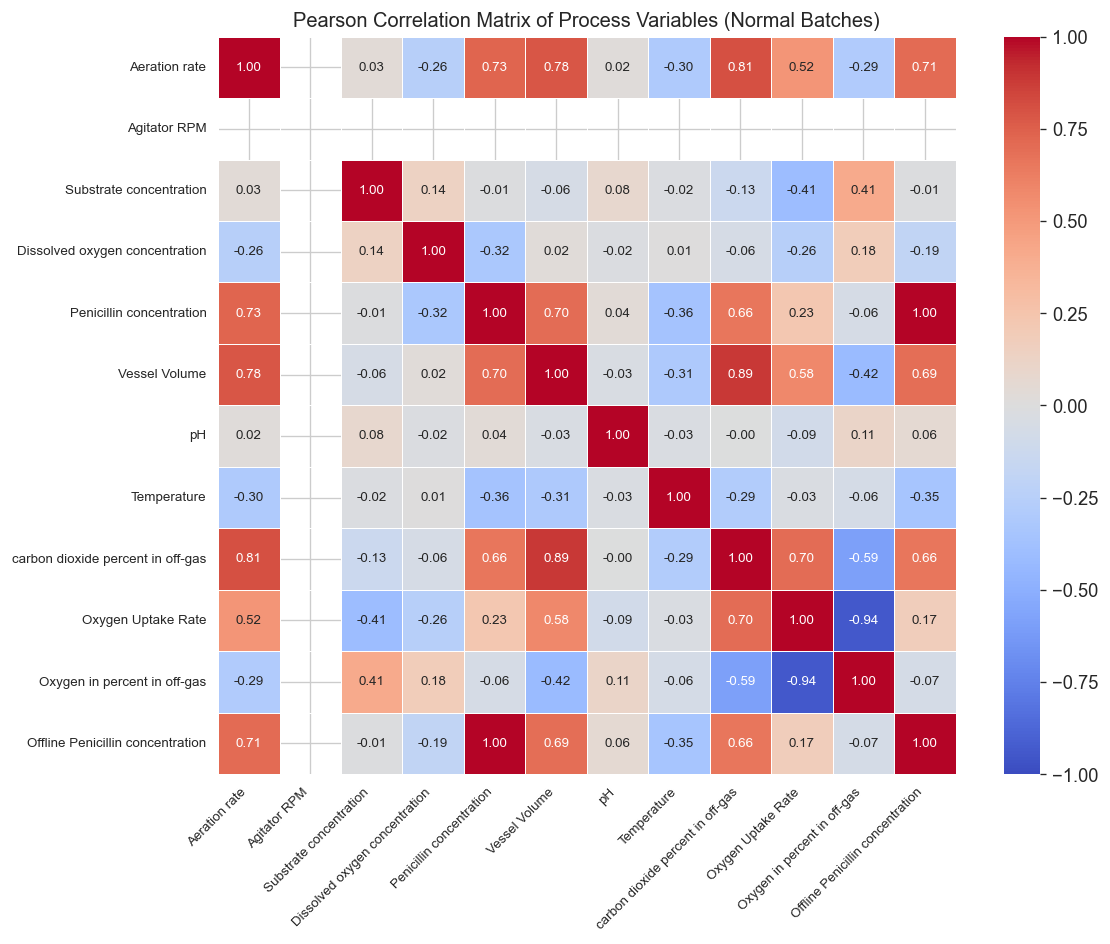

In [18]:
# ── 상관행렬 히트맵 ───────────────────────────────────────
corr_df     = df_no_fault[key_vars].corr(method='pearson')
short_names = [c.split('(')[0].strip() for c in key_vars]
corr_df.index   = short_names
corr_df.columns = short_names

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_df, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}, square=True,
)
ax.set_title('Pearson Correlation Matrix of Process Variables (Normal Batches)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / '01_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [19]:
# ── 강한 상관 변수 쌍 추출 ────────────────────────────────
threshold = 0.8
corr_pairs = []

for i in range(len(corr_df.columns)):
    for j in range(i + 1, len(corr_df.columns)):
        r = corr_df.iloc[i, j]
        if abs(r) >= threshold:
            corr_pairs.append({
                'var_a':    corr_df.columns[i],
                'var_b':    corr_df.columns[j],
                'pearson_r': round(r, 4),
                'direction': 'positive' if r > 0 else 'negative',
            })

high_corr_df = pd.DataFrame(corr_pairs).sort_values('pearson_r', key=abs, ascending=False)
print(f'|r| >= {threshold} 강한 상관 쌍:')
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))
else:
    print('없음')

|r| >= 0.8 강한 상관 쌍:
                   var_a                             var_b  pearson_r direction
Penicillin concentration  Offline Penicillin concentration     1.0000  positive
      Oxygen Uptake Rate      Oxygen in percent in off-gas    -0.9425  negative
           Vessel Volume carbon dioxide percent in off-gas     0.8865  positive
           Aeration rate carbon dioxide percent in off-gas     0.8078  positive


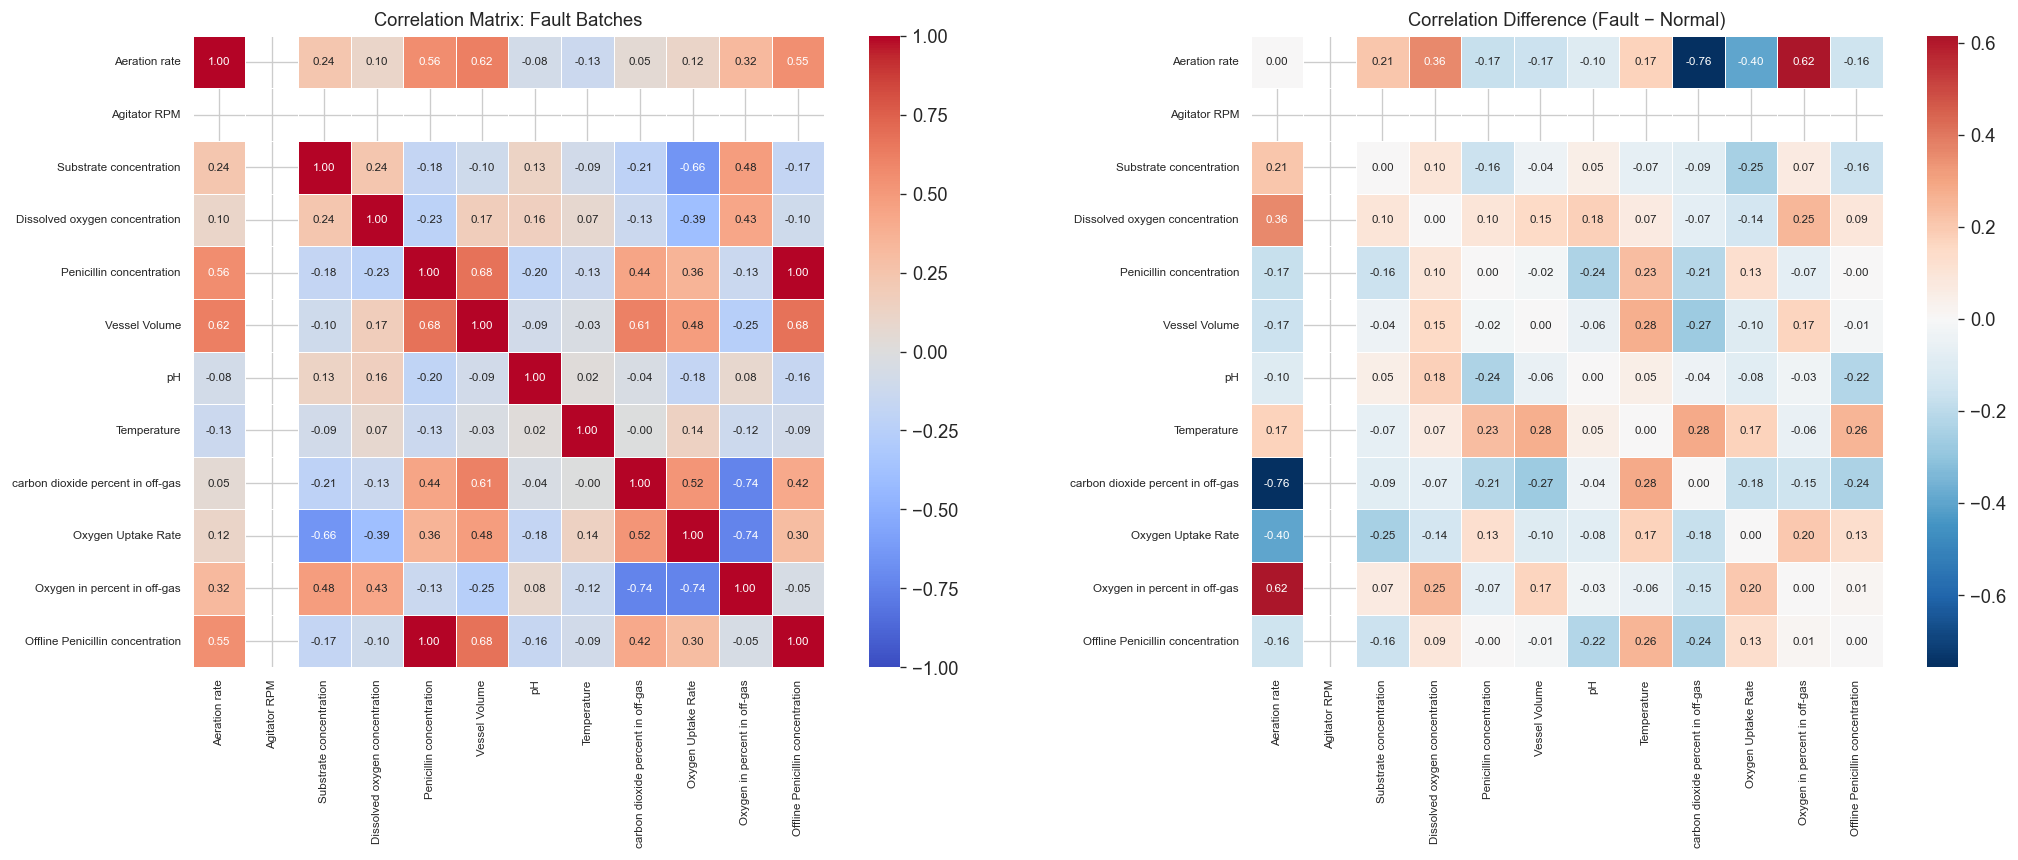

In [20]:
# ── Fault 배치 상관관계 비교 ──────────────────────────────
corr_fault = df_fault[key_vars].corr(method='pearson')
corr_fault.index   = short_names
corr_fault.columns = short_names
corr_diff = corr_fault - corr_df

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    corr_fault, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[0], annot_kws={'size': 7}, square=True,
)
axes[0].set_title('Correlation Matrix: Fault Batches', fontsize=11)
axes[0].tick_params(axis='both', labelsize=7)

sns.heatmap(
    corr_diff, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5, ax=axes[1], annot_kws={'size': 7}, square=True,
)
axes[1].set_title('Correlation Difference (Fault − Normal)', fontsize=11)
axes[1].tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / '01_correlation_fault_vs_normal.png', bbox_inches='tight')
plt.show()

## 8. Fault vs Normal 배치 통계 비교

두 그룹 간 통계적 차이를 검증합니다.

**검정 방법**:
- 정규 분포 가정 시: **독립 표본 t-검정 (Welch's t-test)**
- 정규 분포 불가 시: **Mann-Whitney U 검정** (비모수)

배치 단위 시간 평균값을 비교 기준으로 사용합니다.

In [21]:
# ── Fault vs Normal 그룹 간 통계 검정 ────────────────────
test_results = []

for var in key_vars:
    batch_mean_fault   = df_fault.groupby(BATCH_NUM_COL)[var].mean().dropna().values
    batch_mean_nofault = df_no_fault.groupby(BATCH_NUM_COL)[var].mean().dropna().values

    if len(batch_mean_fault) < 2 or len(batch_mean_nofault) < 2:
        continue

    t_stat, p_ttest = stats.ttest_ind(batch_mean_fault, batch_mean_nofault, equal_var=False)
    u_stat, p_mwu   = stats.mannwhitneyu(batch_mean_fault, batch_mean_nofault, alternative='two-sided')

    pooled_std = np.sqrt((batch_mean_fault.std() ** 2 + batch_mean_nofault.std() ** 2) / 2)
    cohen_d    = (batch_mean_fault.mean() - batch_mean_nofault.mean()) / (pooled_std + 1e-10)

    test_results.append({
        'variable':     var.split('(')[0].strip(),
        'normal_mean':  round(batch_mean_nofault.mean(), 4),
        'fault_mean':   round(batch_mean_fault.mean(), 4),
        'ttest_pvalue': round(p_ttest, 4),
        'mwu_pvalue':   round(p_mwu, 4),
        'cohens_d':     round(cohen_d, 3),
        'significance': 'significant' if p_ttest < 0.05 else 'not significant',
    })

test_df = pd.DataFrame(test_results).sort_values('cohens_d', key=abs, ascending=False)
col_labels = {
    'variable': '변수', 'normal_mean': 'Normal 평균', 'fault_mean': 'Fault 평균',
    'ttest_pvalue': 't-검정 p값', 'mwu_pvalue': 'MWU p값',
    'cohens_d': "Cohen's d", 'significance': '유의(α=0.05)',
}
print('Fault vs Normal 통계 검정 결과:')
print(test_df.rename(columns=col_labels).to_string(index=False))

Fault vs Normal 통계 검정 결과:
                               변수  Normal 평균   Fault 평균  t-검정 p값  MWU p값  Cohen's d      유의(α=0.05)
               Oxygen Uptake Rate     1.2904     1.0131   0.0112  0.0003     -1.321     significant
          Substrate concentration     2.6339    15.1672   0.0215  0.0003      1.233     significant
 Offline Penicillin concentration    14.8263    10.5693   0.0195  0.0073     -1.168     significant
         Penicillin concentration    14.7011    10.6660   0.0206  0.0084     -1.160     significant
                      Temperature   298.0186   298.1004   0.0393  0.0018      1.118     significant
   Dissolved oxygen concentration    12.4926    13.2912   0.0081  0.0093      1.030     significant
                    Vessel Volume 73551.2989 71488.7880   0.0230  0.0137     -1.000     significant
     Oxygen in percent in off-gas     0.1912     0.1931   0.0517  0.0035      0.943 not significant
                    Aeration rate    65.3276    64.4974   0.1027  0.6032  

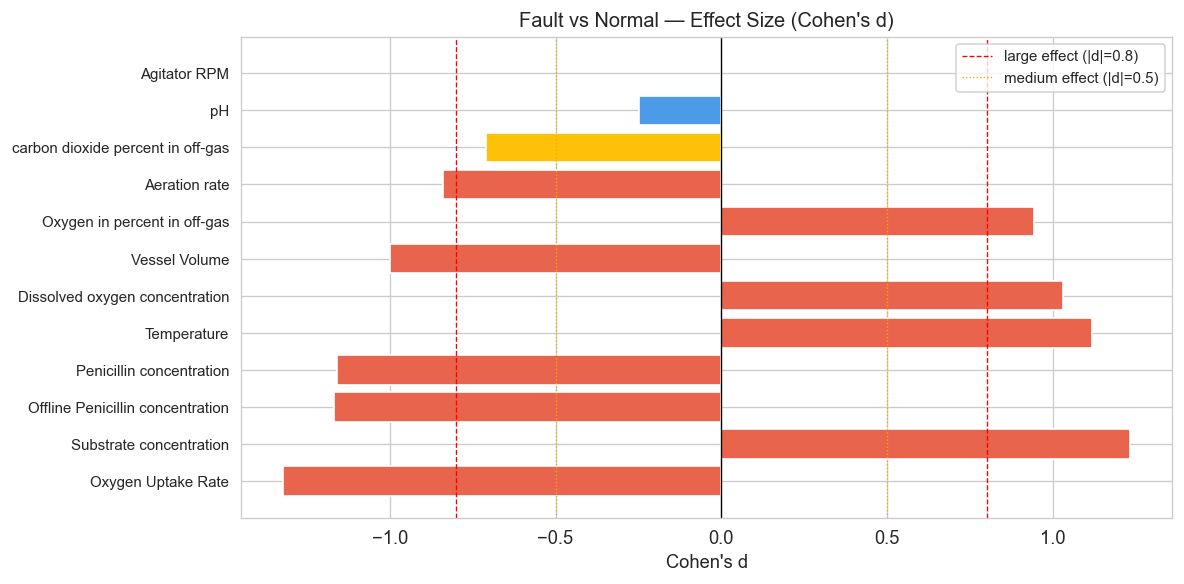

In [22]:
# ── 효과 크기 시각화 ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = [
    '#E8644C' if abs(d) >= 0.8 else ('#FFC107' if abs(d) >= 0.5 else '#4C9BE8')
    for d in test_df['cohens_d']
]

ax.barh(test_df['variable'], test_df['cohens_d'], color=colors)
ax.axvline(0,    color='black',  linewidth=0.8)
ax.axvline( 0.8, color='red',    linewidth=0.8, linestyle='--', label='large effect (|d|=0.8)')
ax.axvline(-0.8, color='red',    linewidth=0.8, linestyle='--')
ax.axvline( 0.5, color='orange', linewidth=0.8, linestyle=':',  label='medium effect (|d|=0.5)')
ax.axvline(-0.5, color='orange', linewidth=0.8, linestyle=':')
ax.set_xlabel("Cohen's d")
ax.set_title("Fault vs Normal — Effect Size (Cohen's d)")
ax.legend(fontsize=9)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / '01_cohens_d_effect_size.png', bbox_inches='tight')
plt.show()

수율 통계 비교:
          Normal      Fault
count       90.0       10.0
mean   3076716.0  2600203.0
std     677186.0  1199611.0
min    1474100.0   890830.0
25%    2605650.0  1736100.0
50%    3185000.0  2275950.0
75%    3587850.0  3592275.0
max    4196000.0  4447700.0

Welch t-test: t=-1.234, p=0.2463
결론: 수율 차이 통계적으로 유의하지 않음 (α=0.05)


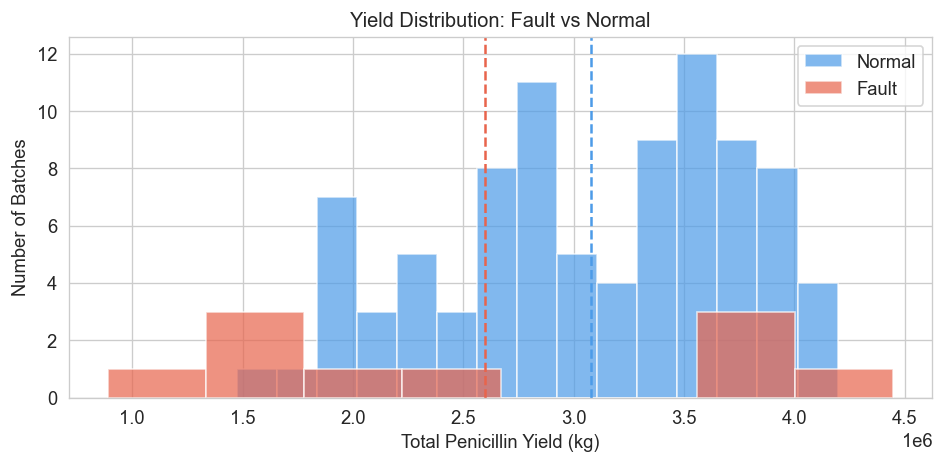

In [23]:
# ── 수율(Yield) 분석 ──────────────────────────────────────
yield_fault   = df_stats[df_stats[FAULT_COL] == 1][YIELD_COL]
yield_nofault = df_stats[df_stats[FAULT_COL] == 0][YIELD_COL]

print('수율 통계 비교:')
print(pd.DataFrame({'Normal': yield_nofault.describe(), 'Fault': yield_fault.describe()}).round(0))

t_stat, p_val = stats.ttest_ind(yield_fault, yield_nofault, equal_var=False)
print(f'\nWelch t-test: t={t_stat:.3f}, p={p_val:.4f}')
print(f'결론: {"수율 차이 유의" if p_val < 0.05 else "수율 차이 통계적으로 유의하지 않음"} (α=0.05)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(yield_nofault, bins=15, alpha=0.7, color=PALETTE['Normal'], label='Normal')
ax.hist(yield_fault,   bins=8,  alpha=0.7, color=PALETTE['Fault'],  label='Fault')
ax.axvline(yield_nofault.mean(), color=PALETTE['Normal'], linestyle='--', linewidth=1.5)
ax.axvline(yield_fault.mean(),   color=PALETTE['Fault'],  linestyle='--', linewidth=1.5)
ax.set_xlabel('Total Penicillin Yield (kg)')
ax.set_ylabel('Number of Batches')
ax.set_title('Yield Distribution: Fault vs Normal')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / '01_yield_distribution.png', bbox_inches='tight')
plt.show()

## 9. 핵심 발견사항 정리

EDA 및 통계 분석에서 발견한 사항을 정리합니다.  
아래 출력은 분석 실행 후 자동으로 갱신됩니다.

In [24]:
# ── 최종 요약 출력 ────────────────────────────────────────
print('=' * 60)
print('EDA 및 통계 분석 핵심 발견사항')
print('=' * 60)
print('[데이터 구조]')
print(f'  총 행 수              : {df.shape[0]:,}')
print(f'  총 컬럼 수            : {df.shape[1]:,}')
print(f'  공정 변수 수          : {len(process_cols)}')
print(f'  라만 채널 수          : {len(raman_cols)}')
print(f'  배치 수               : {df[BATCH_COL].nunique()} (Fault: 10, Normal: 90)')
print()
print('[결측치]')
print(f'  결측치 있는 공정 변수 : {len(missing_nonzero)} 개')
print(f'  라만 기록 비율        : {raman_ratio * 100:.1f}%')
print(f'  배치당 라만 측정 횟수 : 평균 {raman_per_batch.mean():.1f}회')
print()
print('[수율]')
print(f'  Normal 배치 평균 수율 : {yield_nofault.mean():,.0f} +/- {yield_nofault.std():,.0f} kg')
print(f'  Fault  배치 평균 수율 : {yield_fault.mean():,.0f} +/- {yield_fault.std():,.0f} kg')
print()
print('[통계 검정]')
sig_vars = test_df[test_df['significance'] == 'significant']['variable'].tolist()
print(f'  Fault/Normal 차이 유의 변수: {sig_vars if sig_vars else "없음"}')
print()
print('[상관관계]')
print(f'  강한 상관 쌍 수 (|r|>=0.8): {len(high_corr_df)}')
if len(high_corr_df) > 0:
    for _, row in high_corr_df.head(3).iterrows():
        print(f'    {row["var_a"]} <-> {row["var_b"]}: r={row["pearson_r"]}')
print('=' * 60)

EDA 및 통계 분석 핵심 발견사항
[데이터 구조]
  총 행 수              : 113,935
  총 컬럼 수            : 2,240
  공정 변수 수          : 39
  라만 채널 수          : 2200
  배치 수               : 2 (Fault: 10, Normal: 90)

[결측치]
  결측치 있는 공정 변수 : 5 개
  라만 기록 비율        : 1.0%
  배치당 라만 측정 횟수 : 평균 1130.0회

[수율]
  Normal 배치 평균 수율 : 3,076,716 +/- 677,186 kg
  Fault  배치 평균 수율 : 2,600,203 +/- 1,199,611 kg

[통계 검정]
  Fault/Normal 차이 유의 변수: ['Oxygen Uptake Rate', 'Substrate concentration', 'Offline Penicillin concentration', 'Penicillin concentration', 'Temperature', 'Dissolved oxygen concentration', 'Vessel Volume']

[상관관계]
  강한 상관 쌍 수 (|r|>=0.8): 4
    Penicillin concentration <-> Offline Penicillin concentration: r=1.0
    Oxygen Uptake Rate <-> Oxygen in percent in off-gas: r=-0.9425
    Vessel Volume <-> carbon dioxide percent in off-gas: r=0.8865


In [25]:
# ── 통계 결과 CSV 저장 ────────────────────────────────────
desc_all.round(4).to_csv(RESULTS_DIR / 'process_vars_descriptive_stats.csv')
test_df.to_csv(RESULTS_DIR / 'fault_vs_normal_test_results.csv', index=False)
norm_df.to_csv(RESULTS_DIR / 'normality_test_results.csv', index=False)
high_corr_df.to_csv(RESULTS_DIR / 'high_correlation_pairs.csv', index=False)

print('결과 파일 저장 완료:')
print('  - results/process_vars_descriptive_stats.csv')
print('  - results/fault_vs_normal_test_results.csv')
print('  - results/normality_test_results.csv')
print('  - results/high_correlation_pairs.csv')

결과 파일 저장 완료:
  - results/process_vars_descriptive_stats.csv
  - results/fault_vs_normal_test_results.csv
  - results/normality_test_results.csv
  - results/high_correlation_pairs.csv
